In [89]:

import matplotlib.pyplot as plt
import pandas as pd
import torch


In [90]:
data = pd.read_csv('./dataset/Income1.csv')

Text(0, 0.5, 'Income')

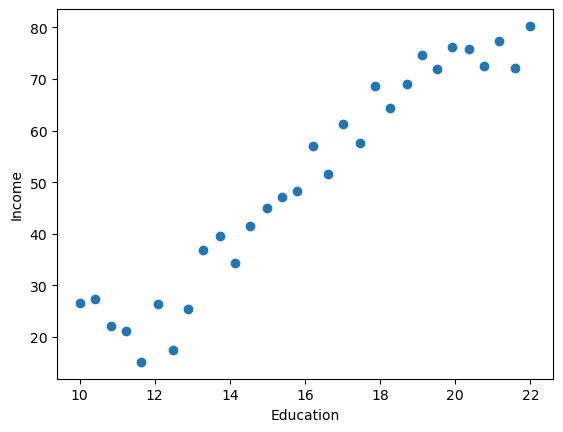

In [91]:
plt.scatter(data.Education, data.Income)
plt.xlabel('Education')
plt.ylabel('Income')

In [92]:
# wx + b

In [93]:
# 分解写法
w = torch.randn(1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

In [94]:
w

tensor([1.0331], requires_grad=True)

In [95]:
b

tensor([0.], requires_grad=True)

In [96]:
learning_rate = 0.001

In [97]:
X = torch.from_numpy(data.Education.values.reshape(-1, 1)).type(torch.FloatTensor)
Y = torch.from_numpy(data.Income.values.reshape(-1, 1)).type(torch.FloatTensor)

In [103]:
w.dim()

1

In [108]:
# # 定义训练过程
# for epoch in range(50):
#     for x, y in zip(X, Y):
#         y_pred = torch.matmul(w, x) + b
#         # 损失函数
#         loss = (y - y_pred).pow(2).sum()

#         # pytorch对一个变量多次求导，求导的结果会累加起来
#         # 梯度归零
#         if w.grad is not None:
#             print(w.grad)
#             w.grad.data.zero_()
#         if b.grad is not None:
#             b.grad.data.zero_()

#         # 反向传播，求w b的导数
#         loss.backward()

#         # 更新w b
#         with torch.no_grad():
#             w.data -= w.grad.data * learning_rate
#             b.data -= b.grad.data * learning_rate
#         print(w)

        # 定义训练过程
for epoch in range(50):
    for x, y in zip(X, Y):
        # y_pred = torch.matmul(x, w) + b
        y_pred = torch.matmul(w, x) + b
        # y_pred = w * x + b
        # 损失函数
        loss = (y - y_pred).pow(2).sum()
        
        # pytorch对一个变量多次求导, 求导的结果会累加起来. 
        if w.grad is not None:
            # 重置w的导数
            w.grad.data.zero_()
        if b.grad is not None:
            b.grad.data.zero_()
            
        # 反向传播, 即求w,b的导数
        loss.backward()
        
        # 更新w,b
        with torch.no_grad():
            w.data -= w.grad.data * learning_rate
            b.data -= b.grad.data * learning_rate

In [109]:
w

tensor([4.0076], requires_grad=True)

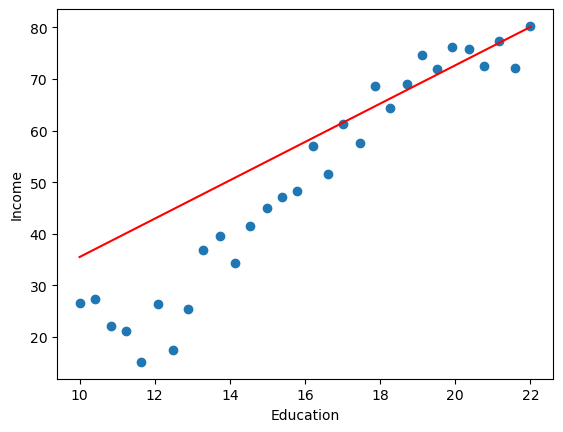

In [101]:
plt.scatter(data.Education, data.Income)
plt.xlabel('Education')
plt.ylabel('Income')
plt.plot(X.numpy(), (torch.matmul(X, w) + b).data.numpy(), c='r')